##6CS012 - Artificial Intelligence and Machine Learning.
##Implementation of Convolutional Neural Network using Keras.

##Student Name: Atul Adhikari
##Student ID: 2408982
##Worksheet5

## Task 1: Data Understanding and Visualization

### 1.1 - Load and Visualize Images

##Unzipping the dataset

In [21]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet 5 Dataset/Copy of FruitinAmazon.zip'
extract_path = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet 5 Dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [22]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# path to the train folder
train_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet 5 Dataset/FruitinAmazon/train'

# get all class folders from train directory
class_names = os.listdir(train_dir)
print('Classes found:', class_names)
print('Total classes:', len(class_names))

Classes found: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']
Total classes: 6


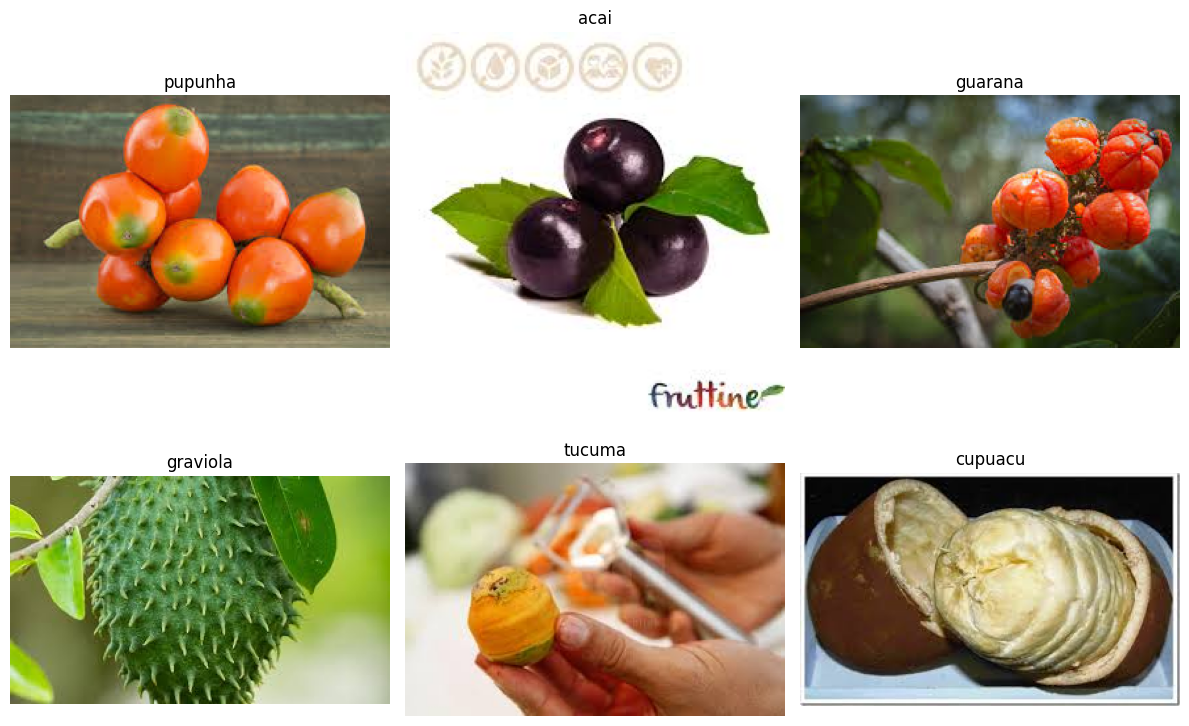

In [23]:
# pick one random image from each class and display in a grid

num_classes = len(class_names)
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
axes = axes.flatten()

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(train_dir, class_name)
    images = os.listdir(class_folder)

    # randomly pick one image
    img_name = random.choice(images)
    img_path = os.path.join(class_folder, img_name)

    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### 1.2 - Check for Corrupted Images

In [24]:
from PIL import Image

corrupted_images = []

for class_name in class_names:
    class_folder = os.path.join(train_dir, class_name)
    for img_file in os.listdir(class_folder):
        image_path = os.path.join(class_folder, img_file)
        try:
            img = Image.open(image_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


## Task 2: Loading and Preprocessing Image Data

In [25]:
import tensorflow as tf
import numpy as np

# image params
img_height = 128
img_width  = 128
batch_size = 16
# 80% train, 20% val
validation_split = 0.2

# normalise pixel values to [0, 1]
rescale = tf.keras.layers.Rescaling(1./255)

# load training data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# apply normalisation
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# load validation data
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# apply normalisation
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Training and validation datasets loaded successfully!")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Training and validation datasets loaded successfully!


In [26]:
# load test data separately
test_dir = '/content/drive/MyDrive/Artificial Intelligence and Machine Learning /Worksheet 5 Dataset/FruitinAmazon/test'

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print("Test dataset loaded!")

Found 30 files belonging to 6 classes.
Test dataset loaded!


In [27]:
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)

Class names: ['pupunha', 'acai', 'guarana', 'graviola', 'tucuma', 'cupuacu']
Number of classes: 6


## Task 3: Implement the CNN Model

In [28]:
from tensorflow.keras import layers, models

# build the CNN
model = models.Sequential()

# Convolutional Block 1
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', strides=1,
                        activation='relu', input_shape=(img_height, img_width, 3)))
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

# Convolutional Block 2
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), padding='same', strides=1,
                        activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2,2), strides=2))

# Fully Connected Layers
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile and Train the Model

In [29]:
# compile with adam optimizer, sparse cross entropy loss and accuracy metric
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# save the best model during training
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# stop training early if val_loss doesn't improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# train the model
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.1292 - loss: 2.1693
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step - accuracy: 0.1250 - loss: 2.1601 - val_accuracy: 0.0000e+00 - val_loss: 1.7771
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.3608 - loss: 1.6720
Epoch 2: val_accuracy improved from 0.00000 to 0.11111, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 310ms/step - accuracy: 0.3611 - loss: 1.6652 - val_accuracy: 0.1111 - val_loss: 1.8091
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.4427 - loss: 1.5181
Epoch 3: val_accuracy improved from 0.11111 to 0.61111, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 508ms/step - accuracy: 0.4583 - loss: 1.4864 - val_accuracy: 0.6111 - val_loss: 1.5050
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6229 - loss: 1.2686
Epoch 4: val_accuracy improved from 0.61111 to 0.66667, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 0.5833 - loss: 1.2739 - val_accuracy: 0.6667 - val_loss: 1.1752
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.6306 - loss: 0.9991
Epoch 5: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 272ms/step - accuracy: 0.6528 - loss: 1.0178 - val_accuracy: 0.6111 - val_loss: 0.8864
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.7108 - loss: 0.7834
Epoch 6: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.7361 - loss: 0.7489 - val_accuracy: 0.3889 - val_loss: 1.8553
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.7649 - loss: 0.6435
Epoch 7: val_accuracy improved from 0.66667 to 0.94444, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 260ms/step - accuracy: 0.7361 - loss: 0.6964 - val_accuracy: 0.9444 - val_loss: 0.5423
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.8802 - loss: 0.4216
Epoch 8: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 277ms/step - accuracy: 0.8333 - loss: 0.4926 - val_accuracy: 0.8333 - val_loss: 0.6169
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.9465 - loss: 0.3061
Epoch 9: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 327ms/step - accuracy: 0.9306 - loss: 0.3293 - val_accuracy: 0.8333 - val_loss: 0.5878
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9837 - loss: 0.1564
Epoch 10: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step - accuracy: 0.9861 - loss: 0.1523 - val_accuracy: 0.8333 - val_loss: 0.6368
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9712 - loss: 0.

### Training and Validation Curves

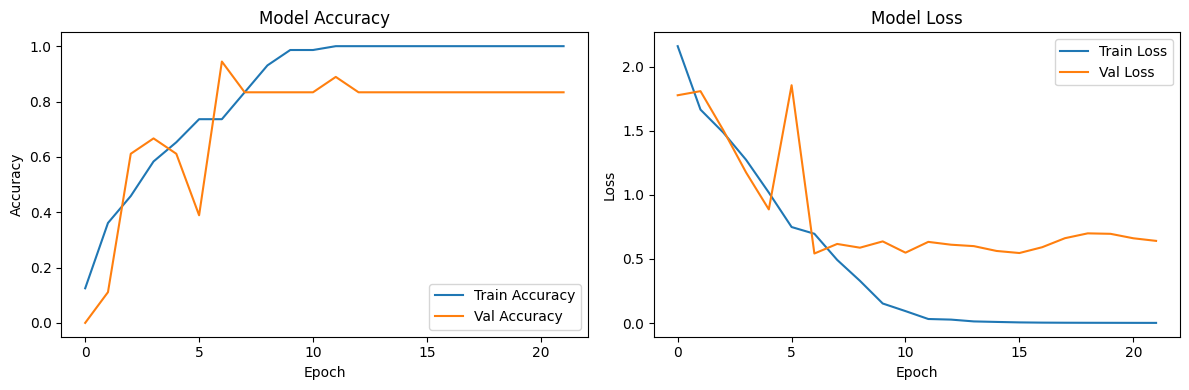

In [31]:
# plot accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate the Model

In [32]:
# evaluate on test set
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5667 - loss: 1.0833 
Test Loss     : 1.0833
Test Accuracy : 0.5667


## Task 6: Save and Load the Model

In [33]:
# save the final trained model
model.save('cnn_fruit_classifier.h5')
print("Model saved as cnn_fruit_classifier.h5")

Model saved as cnn_fruit_classifier.h5


In [34]:
# load the saved model back
from tensorflow.keras.models import load_model

loaded_model = load_model('cnn_fruit_classifier.h5')
print("Model loaded successfully!")

# re-evaluate with the loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy : {loaded_acc:.4f}")

Model loaded successfully!
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.5667 - loss: 1.0833
Loaded Model Test Loss     : 1.0833
Loaded Model Test Accuracy : 0.5667


## Task 7: Predictions and Classification Report

In [35]:
from sklearn.metrics import classification_report

# get true labels and predictions from test dataset
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [36]:
# print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

     pupunha       0.50      1.00      0.67         5
        acai       0.57      0.80      0.67         5
     guarana       1.00      0.40      0.57         5
    graviola       0.00      0.00      0.00         5
      tucuma       0.71      1.00      0.83         5
     cupuacu       0.25      0.20      0.22         5

    accuracy                           0.57        30
   macro avg       0.51      0.57      0.49        30
weighted avg       0.51      0.57      0.49        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


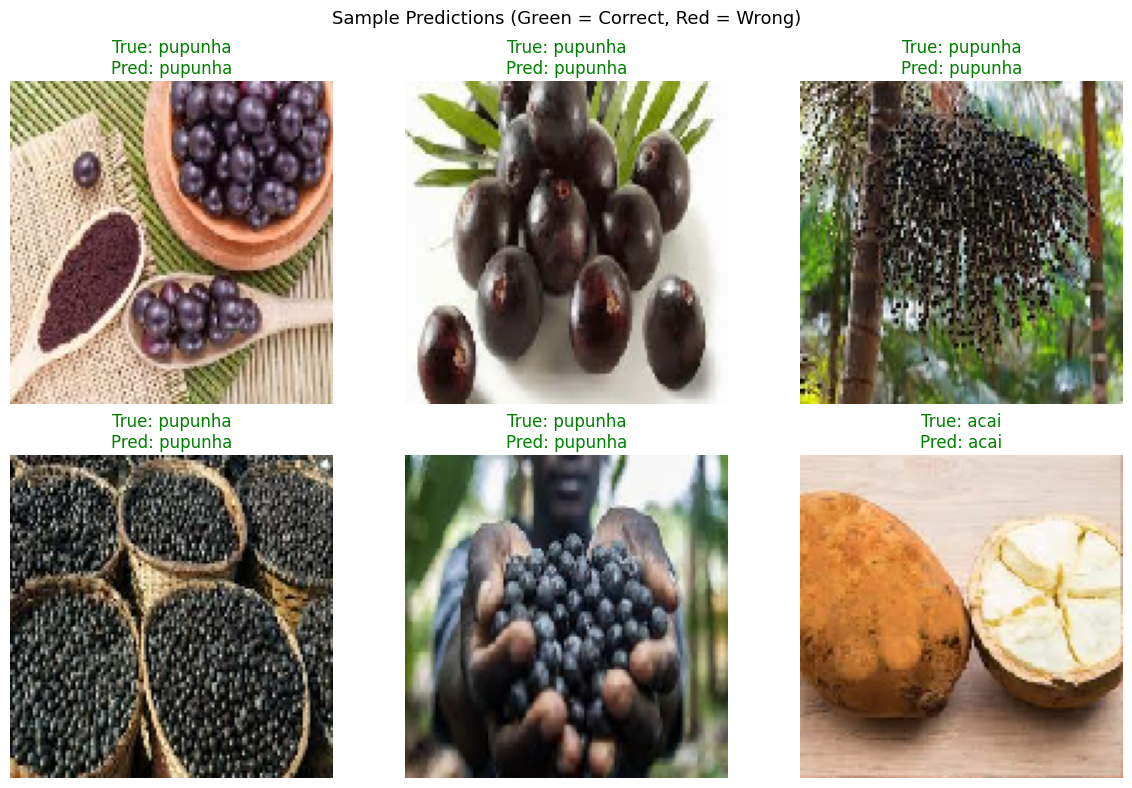

In [37]:
# show a few sample predictions visually
sample_images = []
sample_labels = []

for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

preds = loaded_model.predict(sample_images[:6])
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(sample_images[i])
    true_name = class_names[sample_labels[i]]
    pred_name = class_names[pred_labels[i]]
    color = 'green' if true_name == pred_name else 'red'
    axes[i].set_title(f"True: {true_name}\nPred: {pred_name}", color=color)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green = Correct, Red = Wrong)', fontsize=13)
plt.tight_layout()
plt.show()